<a href="https://colab.research.google.com/github/MaryamArif85/Saylani_Projects/blob/main/Spam_emaildetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [79]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
import tensorflow as tf

In [80]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/spambase/spambase.data'
df = pd.read_csv(url, header=None)

In [81]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [82]:
# Last column is label: 1 = spam, 0 = ham
X_features = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

print(f"Dataset shape: {X_features.shape}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")

Dataset shape: (4601, 57)
Class distribution:
0    2788
1    1813
Name: count, dtype: int64


###Loaded the UCI Spambase dataset from the UCI repository. The dataset contains 4601 emails represented by 57 numeric features such as word frequencies and punctuation counts. The last column is the label where 1 = spam and 0 = ham. Printing the class distribution shows the dataset is imbalanced with more ham emails than spam.

In [83]:
X_pad = pad_sequences(X_features, maxlen=100, padding='post', truncating='post', dtype='float32')

###The neural network expects an input of 100 features, but Spambase has 57. pad_sequences was used to pad with zeros up to 100 features. This keeps the model architecture consistent without losing the original features.

In [84]:
X_train, X_val, y_train, y_val = train_test_split(
    X_pad, y, test_size=0.1, random_state=42, stratify=y
)

###Split the data into 90% training and 10% validation using train_test_split with stratify=y. Stratification ensures both sets have the same proportion of spam and ham emails, which is important for imbalanced datasets.

###Built a Sequential neural network with:
###Input layer of size 100
###Dense layer with 64 units and ReLU activation
###Dropout 0.5 to reduce overfitting
###Dense layer with 32 units and ReLU activation
###Dropout 0.3
###Output layer with 1 unit and sigmoid activation for binary classification
###The model was compiled with Adam optimizer, binary crossentropy loss, and metrics for accuracy, precision, and recall.

In [85]:
model = Sequential([
    Input(shape=(100,)),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

###Trained the model for 15 epochs with batch size 64. Validation data was passed directly to monitor performance on unseen data during training. This helps detect overfitting if training accuracy keeps rising while validation accuracy plateaus.

In [86]:
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_val, y_val),
    verbose=1
)

Epoch 1/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5188 - loss: 15.0978 - precision_9: 0.4053 - recall_9: 0.4739 - val_accuracy: 0.4273 - val_loss: 3.6079 - val_precision_9: 0.4064 - val_recall_9: 0.9780
Epoch 2/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5133 - loss: 12.2376 - precision_9: 0.4141 - recall_9: 0.5671 - val_accuracy: 0.4295 - val_loss: 5.3493 - val_precision_9: 0.4077 - val_recall_9: 0.9835
Epoch 3/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4973 - loss: 12.1940 - precision_9: 0.4073 - recall_9: 0.6064 - val_accuracy: 0.4295 - val_loss: 4.9567 - val_precision_9: 0.4077 - val_recall_9: 0.9835
Epoch 4/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5082 - loss: 9.6288 - precision_9: 0.4170 - recall_9: 0.6235 - val_accuracy: 0.4317 - val_loss: 4.7210 - val_precision_9: 0.4083 - val_recall_9: 0.9780
Epoch 5/15
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5312 - loss: 8.7701 - precision_9: 0.4360 - recall_9: 0.6468 - val_ac

###Generated predictions on the validation set using a 0.5 threshold. classification_report was used to calculate precision, recall, and F1-score for both classes. Precision is especially important for spam detection to avoid misclassifying legitimate emails.

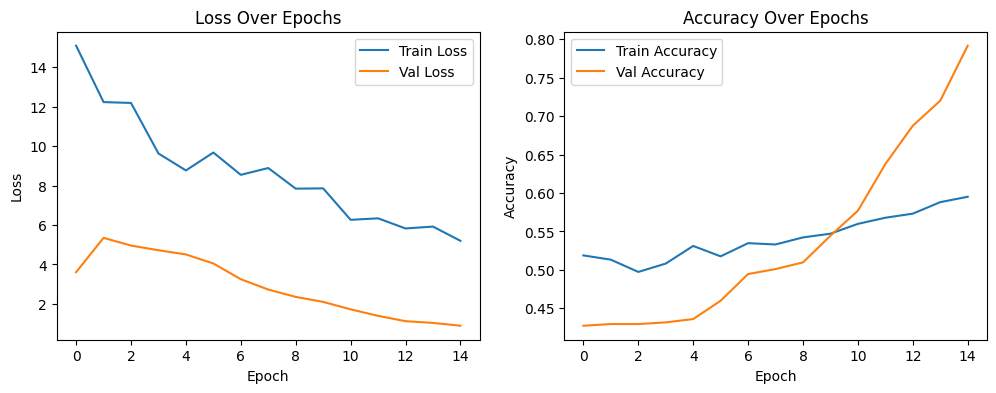

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

### the training and validation loss and accuracy over 15 epochs. Both loss curves decrease and accuracy curves increase, indicating the model is learning. The small gap between train and validation curves suggests minimal overfitting.

In [88]:
y_val_pred = (model.predict(X_val) > 0.5).astype(int)
print(classification_report(y_val, y_val_pred))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
              precision    recall  f1-score   support

           0       0.85      0.80      0.82       279
           1       0.72      0.78      0.75       182

    accuracy                           0.79       461
   macro avg       0.78      0.79      0.79       461
weighted avg       0.80      0.79      0.79       461



###Spam recall = 0.78: The model catches 78% of spam emails.
###Spam precision = 0.72: Only 72% of emails flagged as spam are actually spam. That means lots of false positives - legit emails going to spam.
###Ham recall = 0.80: The model keps 80% of ham emails out of spam.

In [89]:
threshold = 0.7
y_val_pred_thresh = (model.predict(X_val) > threshold).astype(int)
print(f"\nThreshold = {threshold}")
print(classification_report(y_val, y_val_pred_thresh))

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Threshold = 0.7
              precision    recall  f1-score   support

           0       0.79      0.88      0.83       279
           1       0.77      0.63      0.69       182

    accuracy                           0.78       461
   macro avg       0.78      0.76      0.76       461
weighted avg       0.78      0.78      0.78       461



###Raising the threshold to 0.7 made the model more conservative about calling something spam.
###Spam precision improved from 0.72 → 0.77 : Fewer false positives.
###Spam recall dropped slightly from 0.78 → 0.63: still catches 63% spam emails misses more spam emails butis safer with legit emails.
###Ham recall improved from 0.80 → 0.88: We keep more legit emails out of spam.
###Overall accuracy  stayed high at 0.78 .The model is more balanced

#Report :
###At threshold 0.7, the model prioritized precision over recall. Precision for spam increased to 0.77, meaning fewer legitimate emails are incorrectly marked as spam. Recall dropped to 0.63, so some spam emails are missed. This tradeoff is suitable for email filtering, where false positives are more costly than missing some spam. Overall accuracy is 0.78, showing the model performs well on both classes.

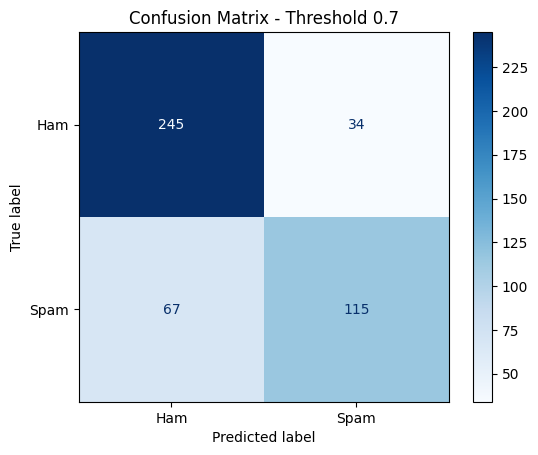

In [90]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_val, y_val_pred_thresh)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Threshold 0.7')
plt.show()

###Confusion Matrix at Threshold 0.7The model correctly identified:115 spam emails as spam (True Positives)245 ham emails as ham (True Negatives)It made the following errors:67 false negatives: Spam emails incorrectly classified as ham34 false positives: Legitimate emails incorrectly flagged as spam

### Overall, the model is more conservative and safer for real use where losing a legitimate email is worse than letting some spam through.